<a href="https://colab.research.google.com/github/engineering-and-analysis-project/DS372-team10/blob/Tareq/Tareq_Milestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

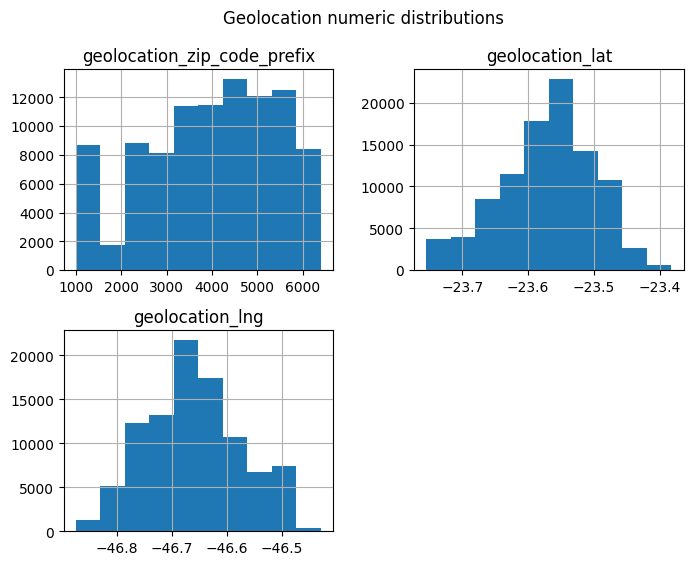

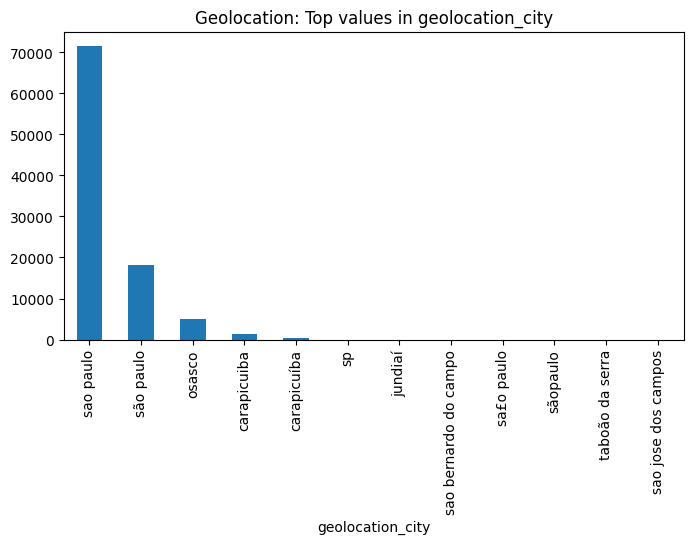

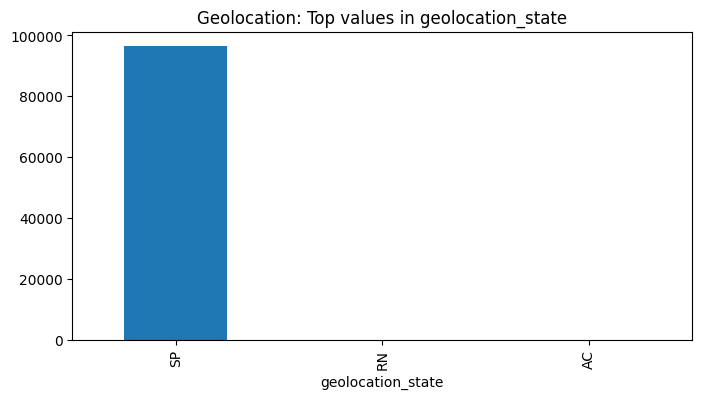

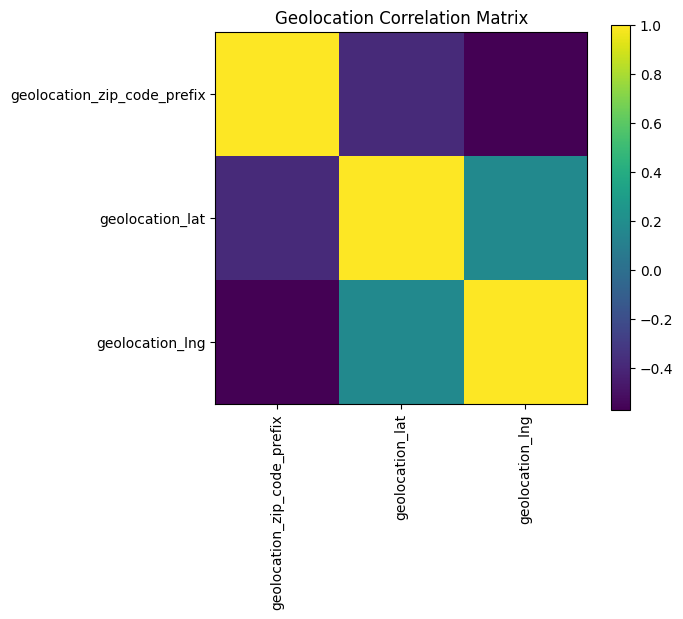

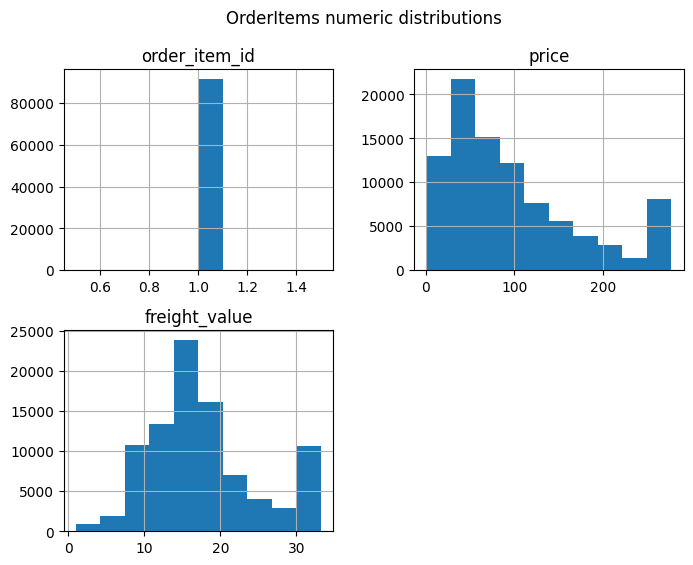

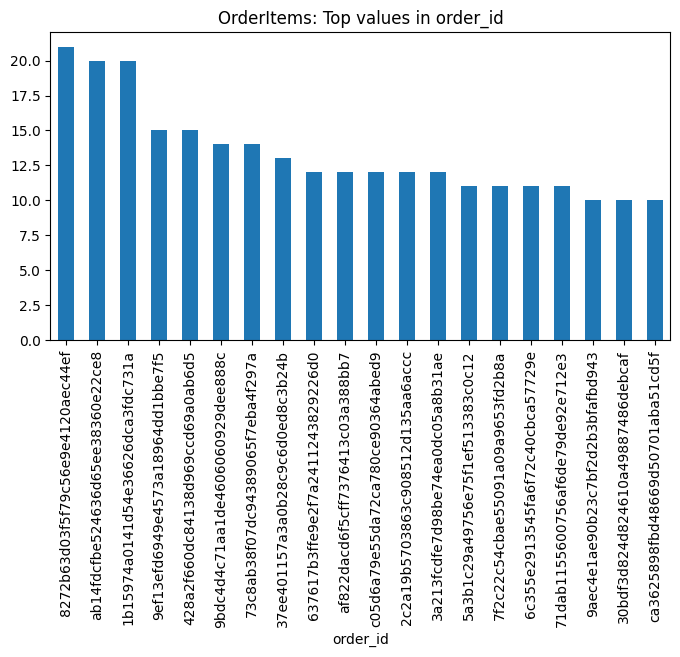

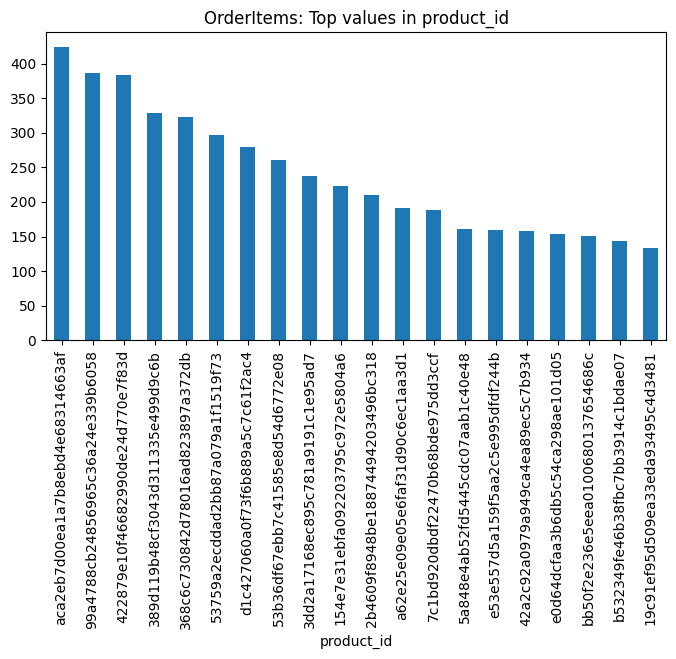

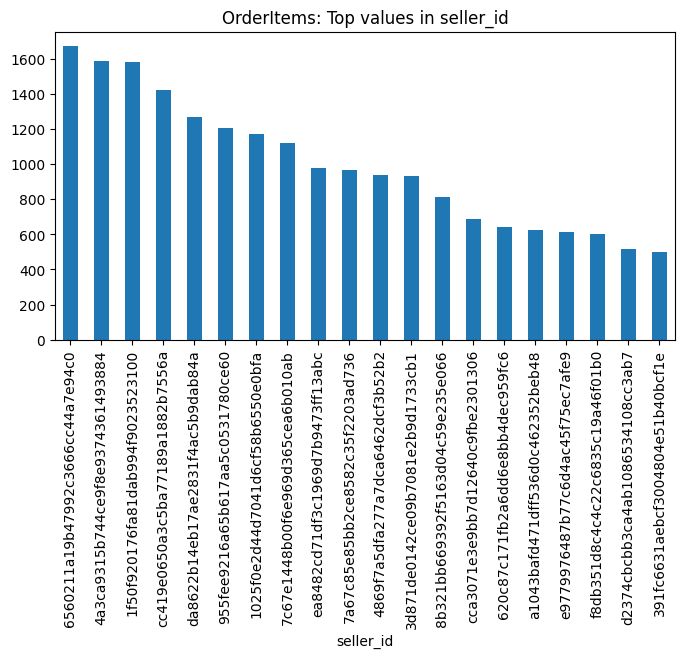

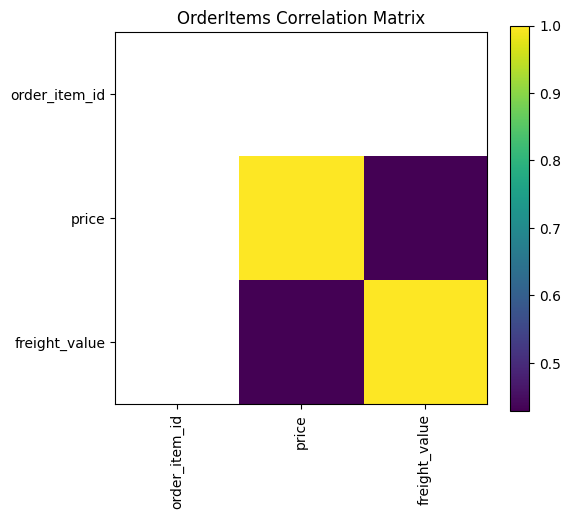

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path

geo_path = "/content/olist_geolocation_dataset.csv"
items_path = "/content/olist_order_items_dataset.csv"

geo = pd.read_csv(geo_path)
items = pd.read_csv(items_path, on_bad_lines='skip')

def drop_high_missing(df, threshold=0.7):
    m = df.isna().mean()
    cols = m[m > threshold].index
    return df.drop(columns=cols)

def impute_simple(df):
    for c in df.columns:
        if df[c].dtype in ["float64", "int64"]:
            df[c] = df[c].fillna(df[c].median())
        else:
            df[c] = df[c].fillna(df[c].mode()[0] if df[c].mode().size > 0 else "missing")
    return df

def remove_duplicates(df):
    return df.drop_duplicates()

def cap_outliers_iqr(df):
    for c in df.columns:
        if df[c].dtype in ["float64", "int64"]:
            q1 = df[c].quantile(0.25)
            q3 = df[c].quantile(0.75)
            iqr = q3 - q1
            low = q1 - 1.5 * iqr
            high = q3 + 1.5 * iqr
            df[c] = np.where(df[c] < low, low, df[c])
            df[c] = np.where(df[c] > high, high, df[c])
    return df

def run_eda(df, name):
    df.hist(figsize=(8, 6))
    plt.suptitle(f"{name} numeric distributions")
    plt.show()
    if df.select_dtypes(include="object").shape[1] > 0:
        for c in df.select_dtypes(include="object").columns[:3]:
            df[c].value_counts().head(20).plot(kind="bar", figsize=(8, 4))
            plt.title(f"{name}: Top values in {c}")
            plt.show()
    num = df.select_dtypes(include=["float64", "int64"])
    if num.shape[1] > 1:
        plt.figure(figsize=(6, 5))
        plt.imshow(num.corr(), cmap="viridis")
        plt.xticks(range(len(num.columns)), num.columns, rotation=90)
        plt.yticks(range(len(num.columns)), num.columns)
        plt.title(f"{name} Correlation Matrix")
        plt.colorbar()
        plt.show()

geo_clean = drop_high_missing(geo)
items_clean = drop_high_missing(items)

geo_clean = impute_simple(geo_clean)
items_clean = impute_simple(items_clean)

geo_clean = remove_duplicates(geo_clean)
items_clean = remove_duplicates(items_clean)

geo_clean = cap_outliers_iqr(geo_clean)
items_clean = cap_outliers_iqr(items_clean)

run_eda(geo_clean, "Geolocation")
run_eda(items_clean, "OrderItems")

merge_key_candidates = [
    ("seller_zip_code_prefix", "geolocation_zip_code_prefix"),
    ("customer_zip_code_prefix", "geolocation_zip_code_prefix")
    # Removed: ("shipping_limit_date", "geolocation_zip_code_prefix") as these are incompatible for merging.
]

merged = None
for left, right in merge_key_candidates:
    if left in items_clean.columns and right in geo_clean.columns:
        # Ensure dtypes are compatible before merging if necessary
        # For example, convert zip codes to string type if they are mixed
        items_clean[left] = items_clean[left].astype(str)
        geo_clean[right] = geo_clean[right].astype(str)
        merged = items_clean.merge(geo_clean, left_on=left, right_on=right, how="left")
        break

Path("/mnt/data").mkdir(exist_ok=True)

items_clean.to_csv("/mnt/data/cleaned_order_items.csv", index=False)
geo_clean.to_csv("/mnt/data/cleaned_geolocation.csv", index=False)
if merged is not None:
    merged.to_csv("/mnt/data/merged_items_geo.csv", index=False)

conn = sqlite3.connect("/mnt/data/etl_example.db")
items_clean.to_sql("order_items", conn, if_exists="replace", index=False)
geo_clean.to_sql("geolocation", conn, if_exists="replace", index=False)
if merged is not None:
    merged.to_sql("items_geolocation_merged", conn, if_exists="replace", index=False)
conn.close()